# cGAN Analysis Notebook

In [1]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

PLOT_STYLE = {
    'style': 'whitegrid',  
    'palette': 'deep',
    'font_scale': 2.0,
    'figsize': (6, 6),
    'rc_overrides': { 'figure.dpi': 100, 'savefig.dpi': 150 },
}

def apply_plot_style_dict(d):
    sns.set_style(d.get('style', 'whitegrid'))
    pal = d.get('palette', None)
    if pal:
        try:
            sns.set_palette(pal)
        except Exception:
            pass
    sns.set_context('notebook', font_scale=d.get('font_scale', 1.0))

    rc = {
        'figure.figsize': d.get('figsize', (8, 6)),
        'axes.titlesize': max(10, 12 * d.get('font_scale', 1.0)),
        'axes.labelsize': max(9, 10 * d.get('font_scale', 1.0)),
        'xtick.labelsize': max(8, 9 * d.get('font_scale', 1.0)),
        'ytick.labelsize': max(8, 9 * d.get('font_scale', 1.0)),
        'legend.fontsize': max(8, 9 * d.get('font_scale', 1.0)),
        'axes.grid': True,
    }
    rc.update(d.get('rc_overrides', {}))
    matplotlib.rcParams.update(rc)

# Apply the style immediately for all subsequent cells
apply_plot_style_dict(PLOT_STYLE)


In [2]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.decomposition import PCA
import umap

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ROOT = Path.cwd()
CHECKPOINT_PATH = ROOT / "cgan_100.pt"

print(f"Using device: {DEVICE}")
print(f"Checkpoint path: {CHECKPOINT_PATH.resolve()}")

c:\Users\sbrad\.conda\envs\soldet_reproduce\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Using device: cuda
Checkpoint path: C:\Users\sbrad\Documents\Uni\In-this-deep-together\Improve\Simulate new data\The_way\cgan_100.pt


In [3]:
# Define the classes for the generator and discriminator
class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int,
        cond_dim: int,
        embed_dim: int,
        base_channels: int = 128,
    ):
        super().__init__()

        self.cond_embed = nn.Sequential(
            nn.Linear(cond_dim, embed_dim),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.init_h = 33
        self.init_w = 41
        self.init_channels = base_channels

        self.fc = nn.Linear(latent_dim + embed_dim, base_channels * self.init_h * self.init_w)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(base_channels, base_channels // 2, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels // 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(base_channels // 2, base_channels // 4, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels // 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels // 4, 1, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        cond_feat = self.cond_embed(cond)
        x = torch.cat([z, cond_feat], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), self.init_channels, self.init_h, self.init_w)
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(
        self,
        cond_dim: int,
        num_classes: int,
        image_h: int,
        image_w: int,
        base_channels: int = 128,
    ):
        super().__init__()
        self.image_h = int(image_h)
        self.image_w = int(image_w)

        self.features = nn.Sequential(
            nn.Conv2d(2, base_channels // 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels // 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels // 4, base_channels // 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels // 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels // 2, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.final_h = self.image_h // 4
        self.final_w = self.image_w // 4
        feat_dim = base_channels * self.final_h * self.final_w

        self.rf_head = nn.Linear(feat_dim, 1)
        self.cls_head = nn.Linear(feat_dim, num_classes)

        self.pos_head = nn.Linear(base_channels * self.final_w, 1)
        nn.init.uniform_(self.pos_head.weight, -0.01, 0.01)
        nn.init.zeros_(self.pos_head.bias)
        self.pos_feat_norm = nn.LayerNorm(base_channels * self.final_w)

    def forward(self, img: torch.Tensor, cond: torch.Tensor):
        numeric_cond = cond[:, 3:]
        cond_map = numeric_cond.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, self.image_h, self.image_w)
        cond_map = cond_map[:, 0:1, :, :]

        feat = self.features(torch.cat([img, cond_map], dim=1))
        feat_flat = feat.view(feat.size(0), -1)
        rf_logits = self.rf_head(feat_flat).squeeze(1)
        cls_logits = self.cls_head(feat_flat)

        feat_x = feat.mean(dim=2)
        feat_x_flat = self.pos_feat_norm(feat_x.view(feat_x.size(0), -1))
        pos_pred = self.pos_head(feat_x_flat).squeeze(1)
        return rf_logits, cls_logits, pos_pred

In [4]:
@dataclass
class CGANBundle:
    generator: Generator
    discriminator: Discriminator
    history: Dict
    epoch: int
    latent_dim: int
    cond_dim: int
    embed_dim: int
    num_classes: int
    image_h: int
    image_w: int


def make_condition_tensor(
    cond_dim: int,
    class_idx: int,
    position: float = 0.0,
    valid_excitation: Optional[float] = None,
    quality: float = 1.0,
    batch_size: int = 1,
    device: str = "cpu",
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    # This helper builds exactly the same conditioning vector format used in training.
    # Format is [one_hot_class(3), position, valid_excitation, quality].
    if class_idx not in {0, 1, 2}:
        raise ValueError(f"class_idx must be 0, 1, or 2; got {class_idx}")

    if valid_excitation is None:
        valid_excitation = 1.0 if class_idx == 1 else 0.0

    c = torch.zeros((batch_size, cond_dim), dtype=dtype, device=device)
    c[:, class_idx] = 1.0
    c[:, 3] = float(np.clip(position, -1.0, 1.0))
    c[:, 4] = 1.0 if float(valid_excitation) >= 0.5 else 0.0
    c[:, 5] = float(np.clip(quality, 0.0, 1.0))

    # Position is only meaningful when excitation is marked valid.
    c[:, 3] = c[:, 3] * c[:, 4]
    return c


def load_cgan_bundle(checkpoint_path: Path, device: str = "cpu") -> CGANBundle:
    # This loader is intentionally strict because silent mismatches can make analysis meaningless.
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint does not exist: {checkpoint_path}")

    payload = torch.load(checkpoint_path, map_location=device)
    cfg = payload.get("config", {})

    latent_dim = int(cfg["latent_dim"])
    cond_dim = int(cfg.get("cond_dim", 6))
    embed_dim = int(cfg["embed_dim"])
    num_classes = int(cfg["num_classes"])
    image_h = int(cfg["image_height"])
    image_w = int(cfg["image_width"])

    generator = Generator(latent_dim, cond_dim, embed_dim).to(device)
    discriminator = Discriminator(cond_dim, num_classes, image_h, image_w).to(device)

    generator.load_state_dict(payload["g_state"])
    discriminator.load_state_dict(payload["d_state"])

    generator.eval()
    discriminator.eval()

    return CGANBundle(
        generator=generator,
        discriminator=discriminator,
        history=payload.get("history", {}),
        epoch=int(payload.get("epoch", -1)),
        latent_dim=latent_dim,
        cond_dim=cond_dim,
        embed_dim=embed_dim,
        num_classes=num_classes,
        image_h=image_h,
        image_w=image_w,
    )

In [5]:
# Load model and metadata once; downstream cells only consume `bundle`.
bundle = load_cgan_bundle(CHECKPOINT_PATH, device=DEVICE)
print("Loaded checkpoint successfully")
print(f"Epoch: {bundle.epoch}")
print(f"latent_dim={bundle.latent_dim}, cond_dim={bundle.cond_dim}, embed_dim={bundle.embed_dim}")
print(f"num_classes={bundle.num_classes}, image=(H={bundle.image_h}, W={bundle.image_w})")

C:\Users\sbrad\AppData\Local\Temp\ipykernel_13516\1552854923.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(checkpoint_path, map_location=device)


Loaded checkpoint successfully
Epoch: 100
latent_dim=128, cond_dim=6, embed_dim=32
num_classes=3, image=(H=132, W=164)


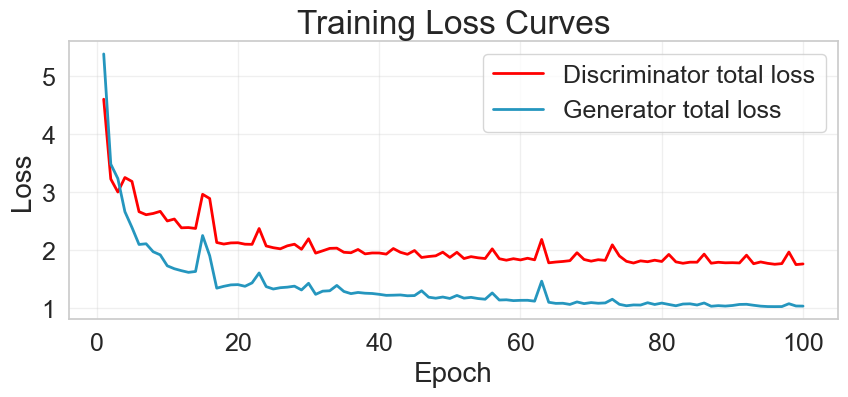

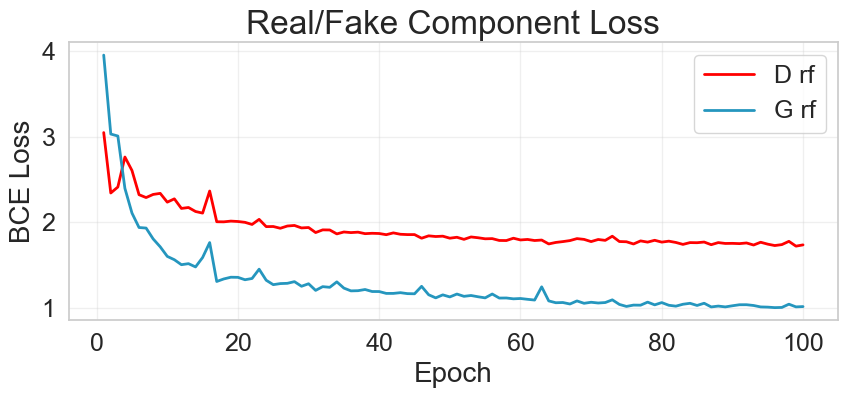

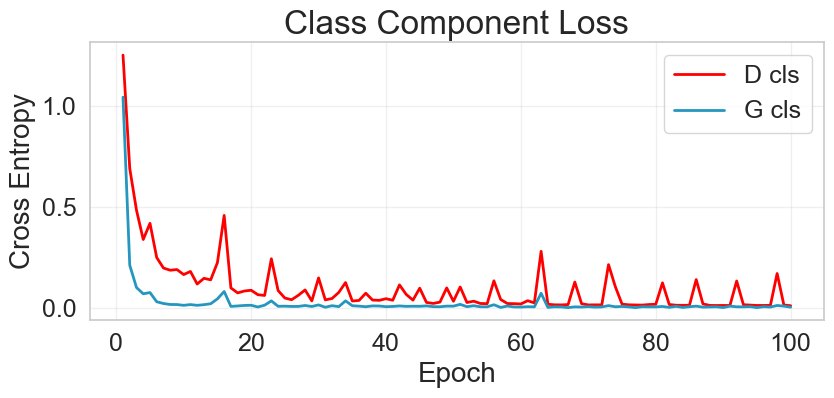

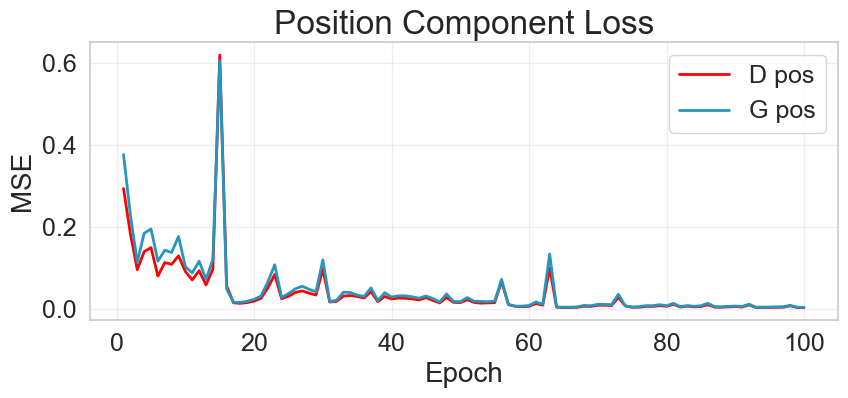

In [6]:
def plot_training_losses(history: Dict) -> None:
    if not history:
        print("No history found in checkpoint payload.")
        return

    d_loss = history.get("d_loss", [])
    g_loss = history.get("g_loss", [])

    epochs = np.arange(1, min(len(d_loss), len(g_loss)) + 1)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
    ax.plot(epochs, d_loss[: len(epochs)], label="Discriminator total loss", linewidth=2, c="#ff0000")
    ax.plot(epochs, g_loss[: len(epochs)], label="Generator total loss", linewidth=2, c="#2596be")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training Loss Curves")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_component_losses(history: Dict, key: str, ylabel: str, title: str) -> None:
    entries_d = history.get("d_loss_components", [])
    entries_g = history.get("g_loss_components", [])

    d_vals = [float(item.get(key, np.nan)) for item in entries_d]
    g_vals = [float(item.get(key, np.nan)) for item in entries_g]
    epochs = np.arange(1, min(len(d_vals), len(g_vals)) + 1)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
    ax.plot(epochs, d_vals[: len(epochs)], label=f"D {key}", linewidth=2, c="#ff0000")
    ax.plot(epochs, g_vals[: len(epochs)], label=f"G {key}", linewidth=2, c="#2596be")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_training_losses(bundle.history)
plot_component_losses(bundle.history, key="rf", ylabel="BCE Loss", title="Real/Fake Component Loss")
plot_component_losses(bundle.history, key="cls", ylabel="Cross Entropy", title="Class Component Loss")
plot_component_losses(bundle.history, key="pos", ylabel="MSE", title="Position Component Loss")

In [7]:
@torch.no_grad()
def sample_generator_outputs(
    bundle: CGANBundle,
    class_idx: int,
    num_samples: int,
    position: float = 0.0,
    quality: float = 1.0,
    seed: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if seed is not None:
        gen = torch.Generator(device=DEVICE).manual_seed(int(seed))
        z = torch.randn(num_samples, bundle.latent_dim, generator=gen, device=DEVICE)
    else:
        z = torch.randn(num_samples, bundle.latent_dim, device=DEVICE)

    cond = make_condition_tensor(
        cond_dim=bundle.cond_dim,
        class_idx=class_idx,
        position=position,
        valid_excitation=(1.0 if class_idx == 1 else 0.0),
        quality=quality,
        batch_size=num_samples,
        device=DEVICE,
    )

    images_t = bundle.generator(z, cond)
    rf_logits, cls_logits, pos_pred = bundle.discriminator(images_t, cond)

    images = images_t.detach().cpu().numpy()[:, 0]  # [N, H, W], still in [-1, 1]
    pred_class = cls_logits.argmax(dim=1).detach().cpu().numpy()
    pred_pos = pos_pred.detach().cpu().numpy()
    return images, pred_class, pred_pos


def display_sample_grid(images: np.ndarray, title: str, ncols: int = 6) -> None:
    n = int(images.shape[0])
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i in range(n):
        img = ((images[i] + 1.0) * 127.5).clip(0, 255)
        axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[i].axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

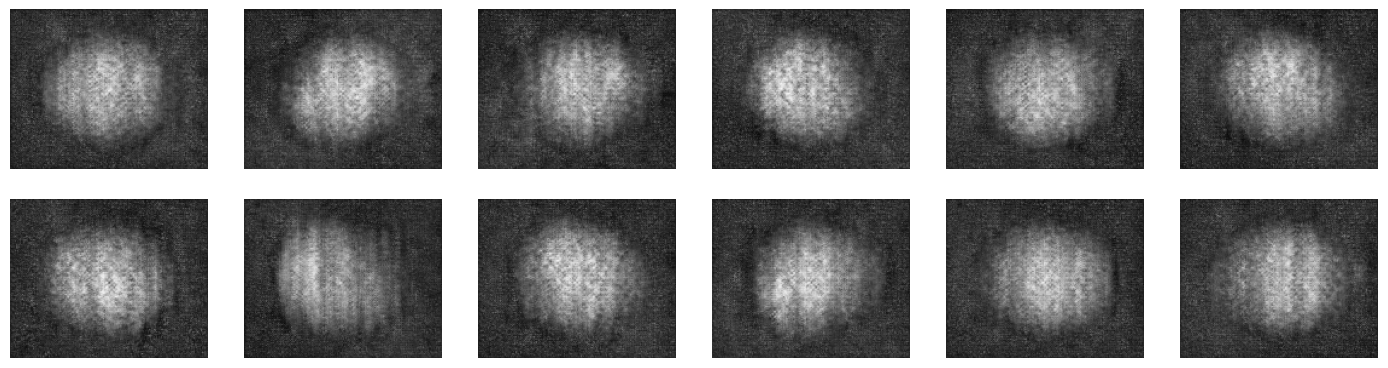

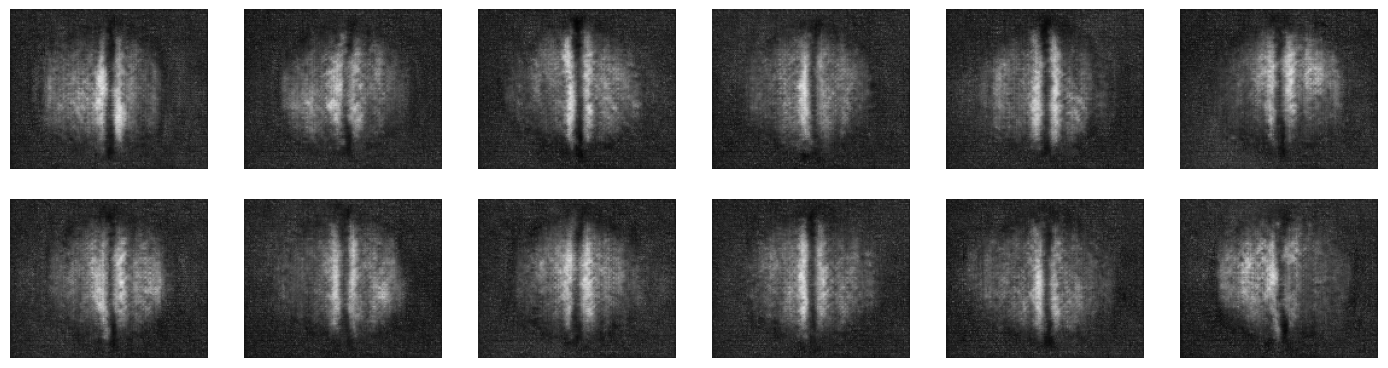

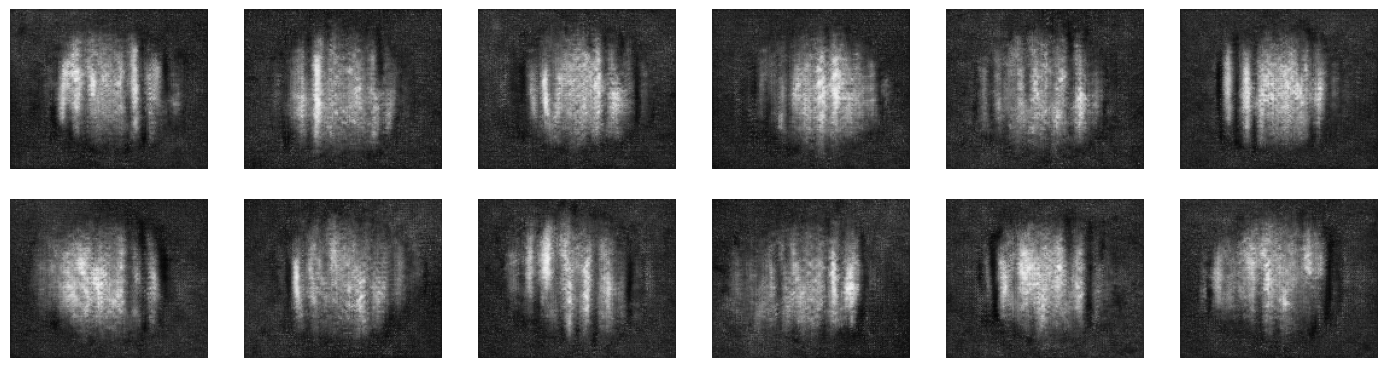

In [8]:
# diversity preview across classes with fixed position and quality
for cls in range(bundle.num_classes):
    imgs, pred_cls, pred_pos = sample_generator_outputs(
        bundle=bundle,
        class_idx=cls,
        num_samples=12,
        position=0.0,
        quality=1.0,
        seed=SEED + cls,
    )
    display_sample_grid(imgs, title=f"Class {cls} qualitative samples", ncols=6)

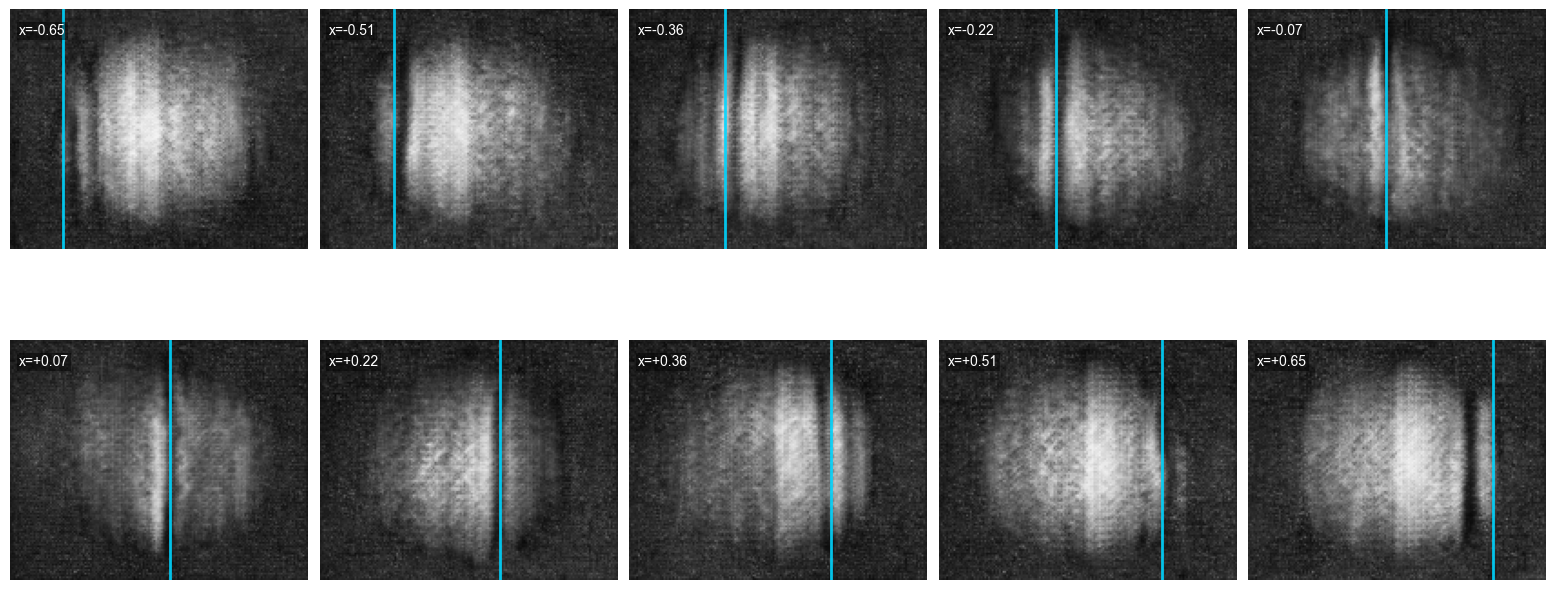

In [9]:
# two-row preview: class 1 with varying soliton positions (10 total)
positions = np.linspace(-0.65, 0.65, 10)
row_images = []

for i, p in enumerate(positions):
    imgs, _, _ = sample_generator_outputs(
        bundle=bundle,
        class_idx=1,
        num_samples=1,
        position=float(p),
        quality=1.0,
        seed=SEED + 500 + i,
    )
    row_images.append(imgs[0])

row_images = np.stack(row_images, axis=0)

nrows, ncols = 2, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.6 * nrows), squeeze=False)
axes = axes.ravel()

for ax, img, p in zip(axes, row_images, positions):
    img_255 = ((img + 1.0) * 127.5).clip(0, 255)
    h, w = img_255.shape
    x_px = ((float(p) + 1.0) * 0.5) * (w - 1)
    ax.imshow(img_255, cmap="gray", vmin=0, vmax=255)
    ax.axvline(x=x_px, color="#00d5ff", linewidth=2.0, alpha=0.9)
    ax.text(
        0.03,
        0.94,
        f"x={p:+.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.45, "pad": 1.5, "edgecolor": "none"},
    )
    ax.axis("off")

for ax in axes[len(positions):]:
    ax.axis("off")

fig.subplots_adjust(left=0.02, right=0.98, bottom=0.03, top=0.90, wspace=0.04, hspace=0.12)
plt.show()

In [10]:
def pairwise_l2_diversity(images: np.ndarray) -> float:
    flat = images.reshape(images.shape[0], -1)
    if flat.shape[0] < 2:
        return 0.0

    dists = []
    for i in range(flat.shape[0]):
        for j in range(i + 1, flat.shape[0]):
            dists.append(np.linalg.norm(flat[i] - flat[j]))
    return float(np.mean(dists))


@torch.no_grad()
def evaluate_label_control(bundle: CGANBundle, samples_per_class: int = 64) -> Dict[str, float]:
    requested = []
    predicted = []
    pos_abs_err = []

    for cls in range(bundle.num_classes):
        imgs, pred_cls, pred_pos = sample_generator_outputs(
            bundle=bundle,
            class_idx=cls,
            num_samples=samples_per_class,
            position=0.25 if cls == 1 else 0.0,
            quality=1.0,
            seed=SEED + 100 + cls,
        )

        requested.extend([cls] * samples_per_class)
        predicted.extend(pred_cls.tolist())

        # Position only applies to class 1 in this conditioning setup.
        if cls == 1:
            target = np.full(samples_per_class, 0.25, dtype=np.float32)
            pos_abs_err.extend(np.abs(pred_pos - target).tolist())

    requested_arr = np.array(requested)
    predicted_arr = np.array(predicted)

    class_consistency = float(np.mean(requested_arr == predicted_arr))
    position_mae = float(np.mean(pos_abs_err)) if len(pos_abs_err) > 0 else np.nan

    return {
        "class_consistency": class_consistency,
        "position_mae_class1": position_mae,
    }


def summarize_diversity(bundle: CGANBundle, samples_per_class: int = 32) -> Dict[str, float]:
    per_class = {}
    for cls in range(bundle.num_classes):
        imgs, _, _ = sample_generator_outputs(
            bundle=bundle,
            class_idx=cls,
            num_samples=samples_per_class,
            position=0.0,
            quality=1.0,
            seed=SEED + 200 + cls,
        )
        per_class[f"diversity_l2_class_{cls}"] = pairwise_l2_diversity(imgs)

    per_class["diversity_l2_mean"] = float(np.mean(list(per_class.values())))
    return per_class


div_metrics = summarize_diversity(bundle, samples_per_class=24)
control_metrics = evaluate_label_control(bundle, samples_per_class=64)

print("Diversity metrics:")
for k, v in div_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nConditional consistency metrics:")
for k, v in control_metrics.items():
    print(f"  {k}: {v:.4f}")

Diversity metrics:
  diversity_l2_class_0: 24.1534
  diversity_l2_class_1: 20.8490
  diversity_l2_class_2: 33.8509
  diversity_l2_mean: 26.2844

Conditional consistency metrics:
  class_consistency: 1.0000
  position_mae_class1: 0.0205


In [11]:
@torch.no_grad()
def collect_generated_flattened_by_class(
    bundle: CGANBundle,
    samples_per_class: int = 120,
) -> Tuple[np.ndarray, np.ndarray]:
    all_x = []
    all_y = []
    for cls in range(bundle.num_classes):
        imgs, _, _ = sample_generator_outputs(
            bundle=bundle,
            class_idx=cls,
            num_samples=samples_per_class,
            position=0.0,
            quality=1.0,
            seed=SEED + 300 + cls,
        )
        all_x.append(imgs.reshape(imgs.shape[0], -1))
        all_y.append(np.full(imgs.shape[0], cls, dtype=np.int32))

    return np.concatenate(all_x, axis=0), np.concatenate(all_y, axis=0)


@torch.no_grad()
def collect_generated_flattened_by_position(
    bundle: CGANBundle,
    class_idx: int = 1,
    samples_per_position: int = 30,
    n_positions: int = 12,
    pos_min: float = -0.65,
    pos_max: float = 0.65,
) -> Tuple[np.ndarray, np.ndarray]:
    all_x = []
    all_pos = []
    positions = np.linspace(pos_min, pos_max, n_positions).astype(np.float32)

    for i, p in enumerate(positions):
        imgs, _, _ = sample_generator_outputs(
            bundle=bundle,
            class_idx=class_idx,
            num_samples=samples_per_position,
            position=float(p),
            quality=1.0,
            seed=SEED + 400 + i,
        )
        all_x.append(imgs.reshape(imgs.shape[0], -1))
        all_pos.append(np.full(imgs.shape[0], p, dtype=np.float32))

    return np.concatenate(all_x, axis=0), np.concatenate(all_pos, axis=0)


def embed_with_pca_umap(X: np.ndarray, pca_dim: int = 50) -> np.ndarray:
    # PCA denoises and reduces compute before UMAP while preserving key structure.
    pca_dim = int(min(pca_dim, X.shape[0] - 1, X.shape[1]))
    X_reduced = PCA(n_components=max(2, pca_dim), random_state=SEED).fit_transform(X)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED,
    )
    return reducer.fit_transform(X_reduced)

class_colors = ["#1f77b4", "#9467bd", "#2ca02c"]  # blue, purple, green


def plot_embedding_by_class(X_2d: np.ndarray, y: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 6.0))
    for cls in sorted(np.unique(y)):
        idx = y == cls
        ax.scatter(X_2d[idx, 0], X_2d[idx, 1], s=14, alpha=0.75, c=class_colors[cls], label=f"class {int(cls)}")
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_embedding_by_position(X_2d: np.ndarray, positions: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 6.0))
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=positions, cmap="viridis", s=14, alpha=0.8)
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("Conditioned position")
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

c:\Users\sbrad\.conda\envs\soldet_reproduce\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


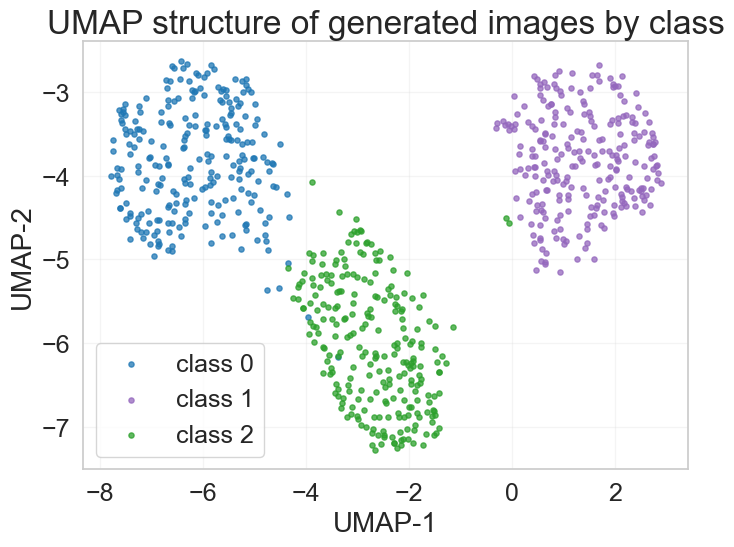

In [12]:
# Latent/output structure by class.
X_cls, y_cls = collect_generated_flattened_by_class(bundle, samples_per_class=250)
X_cls_2d = embed_with_pca_umap(X_cls, pca_dim=200)
plot_embedding_by_class(X_cls_2d, y_cls, title="UMAP structure of generated images by class")

c:\Users\sbrad\.conda\envs\soldet_reproduce\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


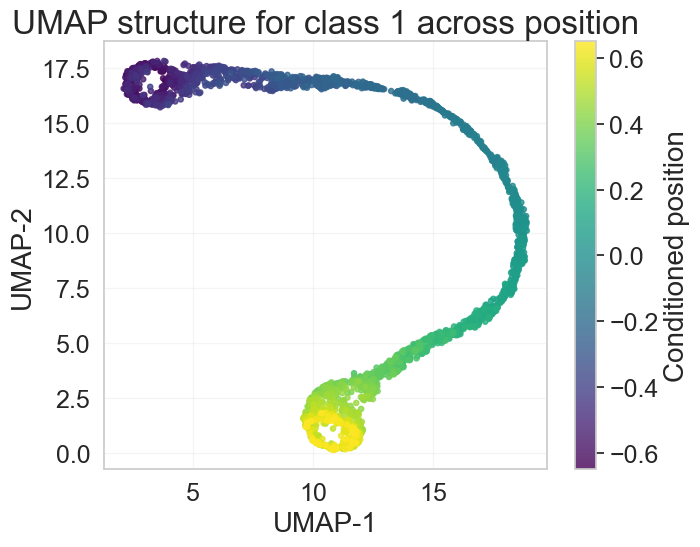

In [13]:
# Latent/output structure by conditioned spatial position for class 1.
X_pos, pos_vals = collect_generated_flattened_by_position(
    bundle,
    class_idx=1,
    samples_per_position=24,
    n_positions=100,
)
X_pos_2d = embed_with_pca_umap(X_pos, pca_dim=50)
plot_embedding_by_position(X_pos_2d, pos_vals, title="UMAP structure for class 1 across position")